<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/main/Qr_Vr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== [Design] 균일 풍량(Uniform Flow)을 위한 가변 면적 설계 ===
 Port_No  Dist(m)  Qp(m3/s)  P_tunnel(Pa)  P_duct(Pa)  dP(Pa)  Area(m2)
       1  100.000    16.000        -0.194    -122.606 122.412     1.652
       2  200.000    16.000         0.121     -89.832  89.952     1.927
       3  300.000    16.000         0.309     -68.308  68.618     2.207
       4  400.000    16.000         0.323     -55.732  56.056     2.441
       5  500.000    16.000         0.200     -49.800  50.000     2.585

=== [Analysis] 동일 면적(2.1624 m2) 적용 시 실제 풍량 및 압력 해석 ===
 Port_No  Dist(m)  Qp_Actual(m3/s)  P_tunnel(Pa)  P_duct(Pa)  dP(Pa)  Area(m2)
       1  100.000           20.401        -0.174    -116.336 116.162     2.162
       2  200.000           17.228         0.214     -82.623  82.838     2.162
       3  300.000           15.137         0.336     -63.609  63.945     2.162
       4  400.000           13.909         0.283     -53.713  53.996     2.162
       5  500.000           13.325         0.152     -49.402  49.55

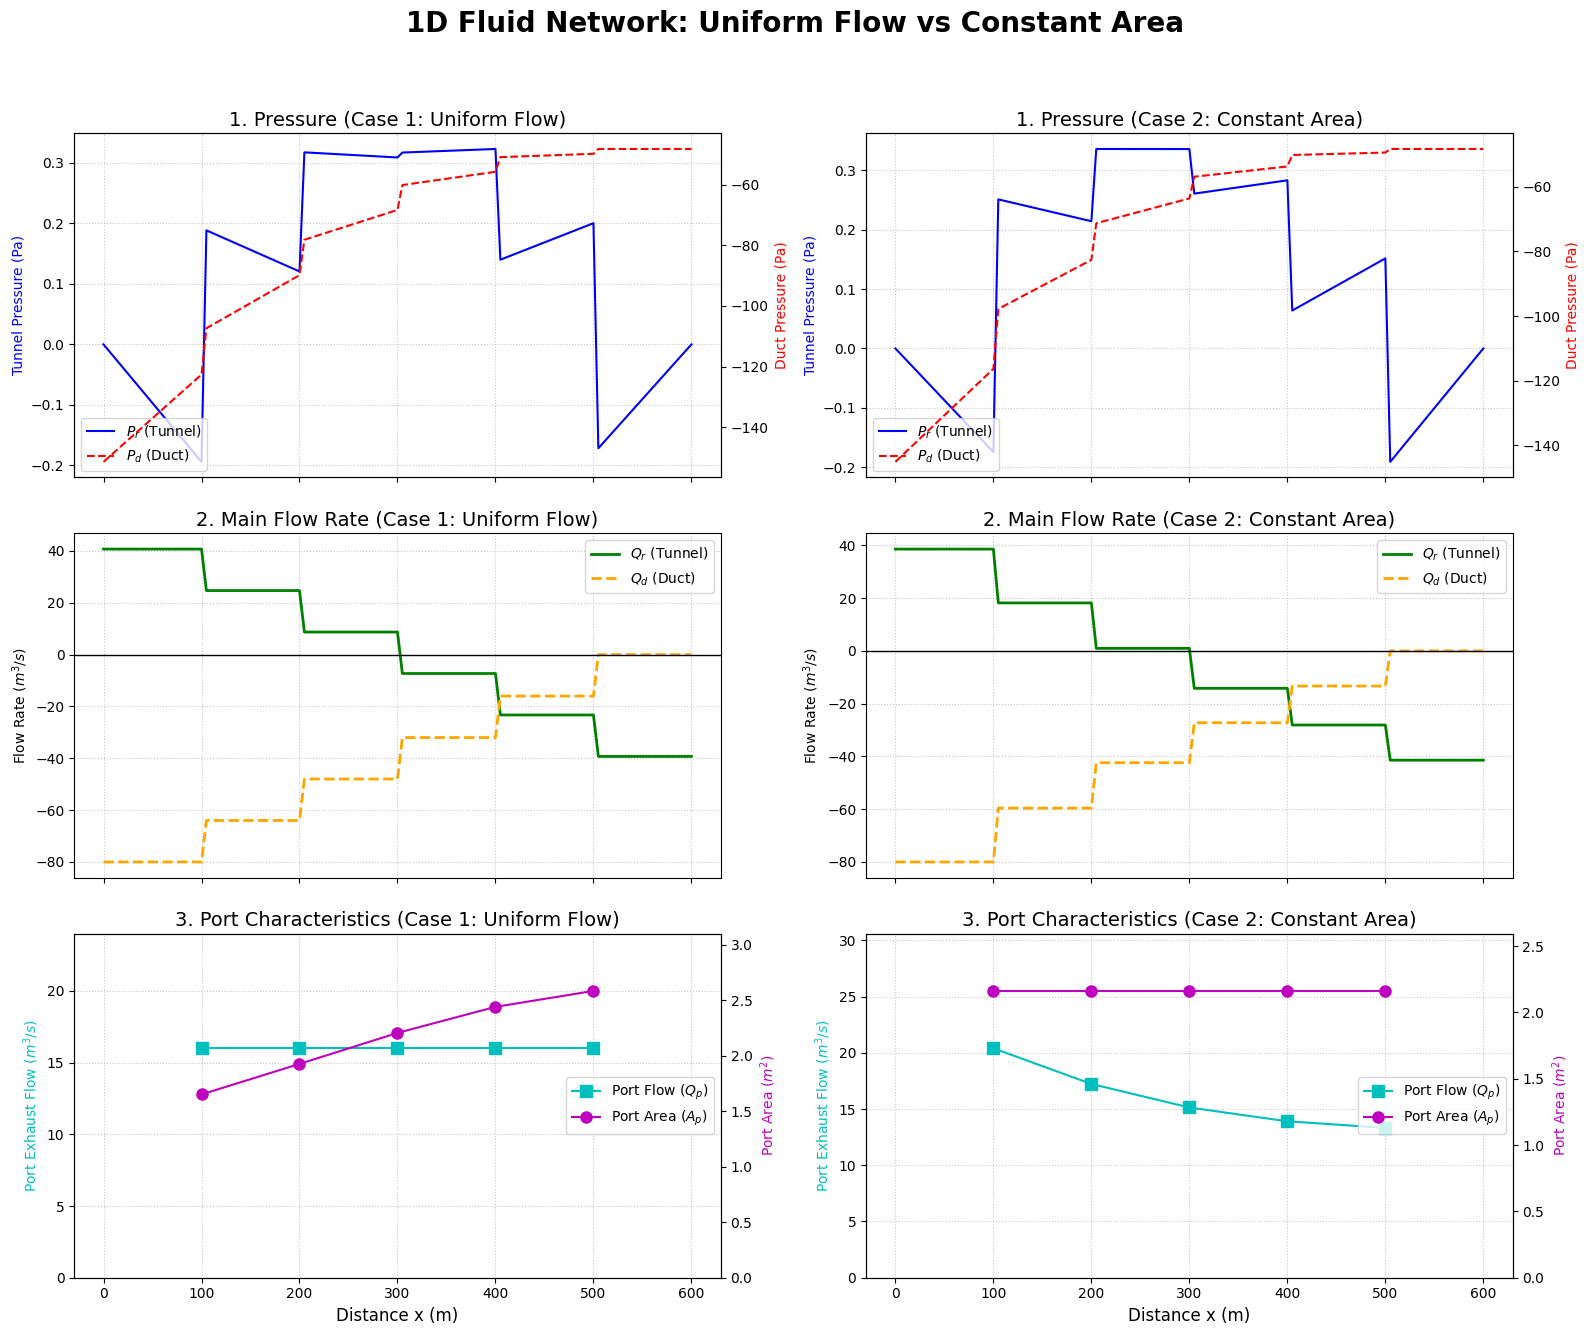

In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 0. Input Parameters
# -----------------------------
L = 600.0                 # Tunnel Length [m]
dx = 5.0                  # Grid spacing [m]
x = np.arange(0.0, L + dx, dx)
N = len(x)

port_positions_all = [10.0, 100.0, 200.0, 300.0, 400.0, 500.0, 590.0]
port_on_off = [False, True, True, True, True, True, False] # 양 끝단 OFF

active_port_positions = [pos for pos, is_on in zip(port_positions_all, port_on_off) if is_on]
active_port_idx = [int(round(pos / dx)) for pos in active_port_positions]

Q_total = 80.0             # Total exhaust target [m3/s]
n_active_ports = len(active_port_positions)

if n_active_ports > 0:
    Qp_target = Q_total / n_active_ports
else:
    Qp_target = 0.0

rho = 1.2
A_r, D_r, f_r = 40.0, 8.0, 0.025
A_d, D_d, f_d = 10.0, 4.0, 0.03

k_mom = 0.5
C_p = 2.175
dP_min_target = 50.0

q_e = np.zeros(N)
for idx in active_port_idx:
    q_e[idx] = Qp_target / dx

# -----------------------------
# 1. BVP Shooting Method (Design Case: Uniform Flow, Variable Area)
# -----------------------------
def calculate_tunnel_pressure(Q_in, q_e_array):
    U_r_temp = np.zeros(N)
    U_r_temp[0] = Q_in / A_r
    for i in range(N - 1):
        U_r_temp[i + 1] = U_r_temp[i] - (q_e_array[i] / A_r) * dx

    P_r_temp = np.zeros(N)
    for i in range(N - 1):
        dU2dx_r = (U_r_temp[i + 1] ** 2 - U_r_temp[i] ** 2) / dx
        fric_r = (f_r / D_r) * (rho / 2.0) * U_r_temp[i] * abs(U_r_temp[i])
        P_r_temp[i + 1] = P_r_temp[i] + (-k_mom * rho * dU2dx_r - fric_r) * dx
    return P_r_temp[-1], U_r_temp, P_r_temp

if n_active_ports > 0:
    q0, q1 =  Q_total/2-5.0, Q_total/2+5.0
    f0 = calculate_tunnel_pressure(q0, q_e)[0]
    f1 = calculate_tunnel_pressure(q1, q_e)[0]
    while abs(f1) > 1e-4:
        q_new = q1 - f1 * (q1 - q0) / (f1 - f0)
        q0, q1 = q1, q_new
        f0, f1 = f1, calculate_tunnel_pressure(q_new, q_e)[0]
    Q_in_exact = q1
else:
    Q_in_exact = 0.0

_, U_r, P_r = calculate_tunnel_pressure(Q_in_exact, q_e)
Q_r = U_r * A_r

# Duct Flow Calculation (Design Case)
U_d = np.zeros(N)
U_d[0] = -Q_total / A_d if n_active_ports > 0 else 0.0
for i in range(N - 1):
    U_d[i + 1] = U_d[i] + (q_e[i] / A_d) * dx
Q_d = U_d * A_d

P_d_temp = np.zeros(N)
for i in range(N - 1):
    dU2dx_d = (U_d[i + 1] ** 2 - U_d[i] ** 2) / dx
    fric_d = (f_d / D_d) * (rho / 2.0) * U_d[i] * abs(U_d[i])
    P_d_temp[i + 1] = P_d_temp[i] + (-k_mom * rho * dU2dx_d - fric_d) * dx

if n_active_ports > 0:
    last_port_idx = active_port_idx[-1]
    shift_amount = dP_min_target - (P_r[last_port_idx] - P_d_temp[last_port_idx])
    P_d = P_d_temp - shift_amount
else:
    P_d = P_d_temp

results = []
if n_active_ports > 0:
    for n, idx in enumerate(active_port_idx, start=1):
        dP_rd = P_r[idx] - P_d[idx]
        A_p = Qp_target / math.sqrt((2.0 * dP_rd) / (rho * C_p)) if dP_rd > 0 else float('nan')
        results.append([n, x[idx], Qp_target, P_r[idx], P_d[idx], dP_rd, A_p])

df_design = pd.DataFrame(results, columns=["Port_No", "Dist(m)", "Qp(m3/s)", "P_tunnel(Pa)", "P_duct(Pa)", "dP(Pa)", "Area(m2)"])

# -----------------------------
# 2. Iterative Analysis (Analysis Case: Constant Area, Variable Flow)
# -----------------------------
if n_active_ports > 0:
    # 앞서 계산된 설계 면적의 평균값을 '동일 기준 면적'으로 설정
    A_const = df_design["Area(m2)"].mean()

    # 반복 해석을 위한 초기 유량 가정 (균일 분배)
    Qp_arr = np.array([Qp_target] * n_active_ports)
    tol = 1e-4
    max_iter = 100

    for iteration in range(max_iter):
        # 2.1 포트별 유량 분포를 배열에 매핑
        q_e_const = np.zeros(N)
        for j, idx in enumerate(active_port_idx):
            q_e_const[idx] = Qp_arr[j] / dx

        # 2.2 터널 압력 해석 (슈팅 메소드)
        q0, q1 = Q_total/2-5.0, Q_total/2+5.0
        f0 = calculate_tunnel_pressure(q0, q_e_const)[0]
        f1 = calculate_tunnel_pressure(q1, q_e_const)[0]
        while abs(f1) > 1e-4:
            q_new = q1 - f1 * (q1 - q0) / (f1 - f0)
            q0, q1 = q1, q_new
            f0, f1 = f1, calculate_tunnel_pressure(q_new, q_e_const)[0]

        _, U_r_const, P_r_const = calculate_tunnel_pressure(q1, q_e_const)
        Q_r_const = U_r_const * A_r

        # 2.3 덕트 내부 유동장 계산
        U_d_const = np.zeros(N)
        U_d_const[0] = -Q_total / A_d
        for i in range(N - 1):
            U_d_const[i + 1] = U_d_const[i] + (q_e_const[i] / A_d) * dx
        Q_d_const = U_d_const * A_d

        P_d_temp_const = np.zeros(N)
        for i in range(N - 1):
            dU2dx_d = (U_d_const[i + 1] ** 2 - U_d_const[i] ** 2) / dx
            fric_d = (f_d / D_d) * (rho / 2.0) * U_d_const[i] * abs(U_d_const[i])
            P_d_temp_const[i + 1] = P_d_temp_const[i] + (-k_mom * rho * dU2dx_d - fric_d) * dx

        # 2.4 Bisection Method를 이용한 덕트 압력 평형점 탐색 (질량 보존 만족)
        def flow_error(shift):
            q_sum = 0.0
            for idx in active_port_idx:
                dp = P_r_const[idx] - (P_d_temp_const[idx] - shift)
                if dp > 0:
                    q_sum += A_const * math.sqrt((2.0 * dp) / (rho * C_p))
            return q_sum - Q_total

        shift_low, shift_high = -5000.0, 5000.0
        # 근 탐색 구간 확보
        while flow_error(shift_low) > 0: shift_low -= 1000.0
        while flow_error(shift_high) < 0: shift_high += 1000.0

        for _ in range(50):
            shift_mid = (shift_low + shift_high) / 2.0
            if flow_error(shift_mid) > 0:
                shift_high = shift_mid
            else:
                shift_low = shift_mid

        P_d_const = P_d_temp_const - shift_mid

        # 2.5 각 포트의 새로운 유량(Qp) 갱신
        Qp_new = np.zeros(n_active_ports)
        for j, idx in enumerate(active_port_idx):
            dp = P_r_const[idx] - P_d_const[idx]
            if dp > 0:
                Qp_new[j] = A_const * math.sqrt((2.0 * dp) / (rho * C_p))

        # 수치 안정성을 위한 Relaxation 적용
        relax_factor = 0.3
        max_diff = np.max(np.abs(Qp_new - Qp_arr))
        Qp_arr = relax_factor * Qp_new + (1 - relax_factor) * Qp_arr

        if max_diff < tol:
            break

    # 해석 결과 데이터프레임 정리
    results_const = []
    for j, idx in enumerate(active_port_idx):
        dp = P_r_const[idx] - P_d_const[idx]
        results_const.append([j+1, x[idx], Qp_arr[j], P_r_const[idx], P_d_const[idx], dp, A_const])

    df_analysis = pd.DataFrame(results_const, columns=["Port_No", "Dist(m)", "Qp_Actual(m3/s)", "P_tunnel(Pa)", "P_duct(Pa)", "dP(Pa)", "Area(m2)"])

# -----------------------------
# 3. 콘솔 출력
# -----------------------------
pd.set_option("display.width", 200)
print("=== [Design] 균일 풍량(Uniform Flow)을 위한 가변 면적 설계 ===")
if not df_design.empty:
    print(df_design.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

print(f"\n=== [Analysis] 동일 면적({A_const:.4f} m2) 적용 시 실제 풍량 및 압력 해석 ===")
if not df_analysis.empty:
    print(df_analysis.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# -----------------------------
# 4. 시각화 (두 케이스 비교)
# -----------------------------
# ---------------------------------------------------------
# PLOTTING: 1D Fluid Network: Uniform Flow vs Uniform Area
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
fig.suptitle('1D Fluid Network: Uniform Flow vs Constant Area', fontsize=20, fontweight='bold')

# --- Row 1: 압력 분포 (터널 & 덕트) ---
# 좌측: 단일 배기량 (Case 1)
ax00 = axs[0, 0]
ax00.plot(x, P_r, 'b-', label='$P_r$ (Tunnel)')
ax00_t = ax00.twinx()
ax00_t.plot(x, P_d, 'r--', label='$P_d$ (Duct)')
ax00.set_title('1. Pressure (Case 1: Uniform Flow)', fontsize=14)
ax00.set_ylabel('Tunnel Pressure (Pa)', color='b')
ax00_t.set_ylabel('Duct Pressure (Pa)', color='r')
ax00.grid(True, linestyle=':', alpha=0.7)
lines = ax00.get_lines() + ax00_t.get_lines()
ax00.legend(lines, [l.get_label() for l in lines], loc='lower left')

# 우측: 단일 면적 (Case 2)
ax01 = axs[0, 1]
ax01.plot(x, P_r_const, 'b-', label='$P_r$ (Tunnel)')
ax01_t = ax01.twinx()
ax01_t.plot(x, P_d_const, 'r--', label='$P_d$ (Duct)')
ax01.set_title('1. Pressure (Case 2: Constant Area)', fontsize=14)
ax01.set_ylabel('Tunnel Pressure (Pa)', color='b')
ax01_t.set_ylabel('Duct Pressure (Pa)', color='r')
ax01.grid(True, linestyle=':', alpha=0.7)
lines = ax01.get_lines() + ax01_t.get_lines()
ax01.legend(lines, [l.get_label() for l in lines], loc='lower left')

# --- Row 2: 차도 및 덕트 풍량 ---
# 좌측: 단일 배기량 (Case 1)
ax10 = axs[1, 0]
ax10.plot(x, Q_r, 'g-', linewidth=2, label='$Q_r$ (Tunnel)')
ax10.plot(x, Q_d, 'orange', linestyle='--', linewidth=2, label='$Q_d$ (Duct)')
ax10.set_title('2. Main Flow Rate (Case 1: Uniform Flow)', fontsize=14)
ax10.set_ylabel('Flow Rate ($m^3/s$)')
ax10.axhline(0, color='k', linewidth=1)
ax10.grid(True, linestyle=':', alpha=0.7)
ax10.legend(loc='best')

# 우측: 단일 면적 (Case 2)
ax11 = axs[1, 1]
ax11.plot(x, Q_r_const, 'g-', linewidth=2, label='$Q_r$ (Tunnel)')
ax11.plot(x, Q_d_const, 'orange', linestyle='--', linewidth=2, label='$Q_d$ (Duct)')
ax11.set_title('2. Main Flow Rate (Case 2: Constant Area)', fontsize=14)
ax11.set_ylabel('Flow Rate ($m^3/s$)')
ax11.axhline(0, color='k', linewidth=1)
ax11.grid(True, linestyle=':', alpha=0.7)
ax11.legend(loc='best')

# --- Row 3: 포트 개구 면적 및 포트 풍량 ---
# 좌측: 단일 배기량 (Case 1) - 풍량은 일정, 면적은 가변
ax20 = axs[2, 0]
ax20.plot(df_design["Dist(m)"], df_design["Qp(m3/s)"], 'c-s', markersize=8, label='Port Flow ($Q_p$)')
ax20_t = ax20.twinx()
ax20_t.plot(df_design["Dist(m)"], df_design["Area(m2)"], 'm-o', markersize=8, label='Port Area ($A_p$)')
ax20.set_title('3. Port Characteristics (Case 1: Uniform Flow)', fontsize=14)
ax20.set_xlabel('Distance x (m)', fontsize=12)
ax20.set_ylabel('Port Exhaust Flow ($m^3/s$)', color='c')
ax20_t.set_ylabel('Port Area ($m^2$)', color='m')
ax20_t.set_ylim(0, df_design["Area(m2)"].max()*1.2)
ax20.set_ylim(0, df_design["Qp(m3/s)"].max()*1.5)
ax20.grid(True, linestyle=':', alpha=0.7)
lines = ax20.get_lines() + ax20_t.get_lines()
ax20.legend(lines, [l.get_label() for l in lines], loc='center right')

# 우측: 단일 면적 (Case 2) - 면적은 일정, 풍량은 가변
ax21 = axs[2, 1]
# [수정됨] "Qp(m3/s)" -> "Qp_Actual(m3/s)" 로 변경
ax21.plot(df_analysis["Dist(m)"], df_analysis["Qp_Actual(m3/s)"], 'c-s', markersize=8, label='Port Flow ($Q_p$)')
ax21_t = ax21.twinx()
ax21_t.plot(df_analysis["Dist(m)"], df_analysis["Area(m2)"], 'm-o', markersize=8, label='Port Area ($A_p$)')
ax21.set_title('3. Port Characteristics (Case 2: Constant Area)', fontsize=14)
ax21.set_xlabel('Distance x (m)', fontsize=12)
ax21.set_ylabel('Port Exhaust Flow ($m^3/s$)', color='c')
ax21_t.set_ylabel('Port Area ($m^2$)', color='m')
ax21_t.set_ylim(0, df_analysis["Area(m2)"].max()*1.2)
ax21.set_ylim(0, df_analysis["Qp_Actual(m3/s)"].max()*1.5) # 여기도 수정됨
ax21.grid(True, linestyle=':', alpha=0.7)
lines = ax21.get_lines() + ax21_t.get_lines()
ax21.legend(lines, [l.get_label() for l in lines], loc='center right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0)
plt.show()